In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

df = pd.read_csv("data.csv")


In [4]:
df.head() 

,student_id,date,program,city,gender,employment_status,age,study_hours_week,sleep_hours,attendance_rate,assignment_score,exam_score,survey_satisfaction,stress_level,monthly_income_pln,season,temperature_c,campaign,website_visits,usual_country,login_country,purchase_amount,transaction_hour,failed_logins_5min,requests_per_minute,batch_id,defective_count
0,1,2026-01-01,Data Science,Warsaw,Female,Part-time,18,9.8,6.2,85.0,78.3,79.1,5.0,7.0,2197.0,Winter,2.7,NaN,1014,Poland,Poland,107.98,20,0,122,B08,0
1,2,2026-01-02,Data Science,Katowice,Male,Student,20,10.1,7.4,98.6,83.4,88.3,3.0,6.0,NaN,Winter,-3.4,Exam Week,1855,Poland,Poland,63.76,16,2,83,B10,1
2,3,2026-01-03,Cybersecurity,Gdansk,Male,Part-time,30,9.6,7.4,82.5,79.5,77.8,3.0,3.0,4319.0,Winter,-0.9,NaN,1079,Poland,Poland,79.54,12,1,111,B12,4
3,4,2026-01-04,Business IT,Krakow,Female,Part-time,31,14.5,7.0,78.6,83.5,75.9,4.0,5.0,4818.0,Winter,4.6,Holiday Promo,2941,Poland,Poland,63.67,21,0,118,B09,5
4,5,2026-01-05,Business IT,Krakow,Female,Full-time,36,1.1,9.9,89.5,84.7,69.1,2.0,3.0,3122.0,Winter,2.1,NaN,838,Poland,Poland,52.60,15,1,104,B01,3


# HANDLING MISSING VALUES MCAR, MAR, MNAR

In [5]:
df.isnull().sum()

student_id              0
date                    0
program                 0
city                    0
gender                  0
employment_status       0
age                     0
study_hours_week        0
sleep_hours             0
attendance_rate         0
assignment_score        0
exam_score              0
survey_satisfaction     6
stress_level            5
monthly_income_pln     13
season                  0
temperature_c           0
campaign               71
website_visits          0
usual_country           0
login_country           0
purchase_amount         0
transaction_hour        0
failed_logins_5min      0
requests_per_minute     0
batch_id                0
defective_count         0
dtype: int64

## **survey_satisfaction** column Missing Values

creating a new column that indices the missing values for survey_satisfaction column
- 0 = not missing 
- 1 = missing

In [6]:
df['survey_satisfaction_missing'] = df['survey_satisfaction'].isna().astype(int)

In [7]:
df[df['survey_satisfaction_missing'] == 1]

,student_id,date,program,city,gender,employment_status,age,study_hours_week,sleep_hours,attendance_rate,assignment_score,exam_score,survey_satisfaction,stress_level,monthly_income_pln,season,temperature_c,campaign,website_visits,usual_country,login_country,purchase_amount,transaction_hour,failed_logins_5min,requests_per_minute,batch_id,defective_count,survey_satisfaction_missing
6,7,2026-01-07,Data Science,Gdansk,Male,Part-time,19,17.4,6.0,86.2,65.0,100.0,NaN,2.0,3784.0,Winter,0.2,Holiday Promo,2775,Poland,Poland,39.45,12,0,68,B09,5,1
22,23,2026-01-23,Business IT,Katowice,Female,Part-time,22,4.1,7.6,82.9,84.8,76.5,NaN,4.0,2996.0,Winter,-0.7,NaN,1061,Poland,Poland,48.40,20,0,137,B04,4,1
40,41,2026-02-10,Business IT,Wroclaw,Female,Full-time,28,4.7,7.0,95.9,56.2,48.7,NaN,1.0,6894.0,Winter,0.3,NaN,838,Poland,Poland,90.40,19,2,100,B02,6,1
77,78,2026-03-19,Data Science,Warsaw,Male,Student,29,14.8,8.1,86.0,65.9,82.0,NaN,3.0,1017.0,Spring,18.9,NaN,1083,Poland,Poland,82.14,10,0,120,B08,5,1
101,102,2026-04-12,Cybersecurity,Gdansk,Male,Part-time,22,10.5,6.1,80.2,55.4,68.1,NaN,3.0,3482.0,Spring,14.1,NaN,1012,Poland,Poland,133.60,18,0,122,B07,3,1
118,119,2026-04-29,Business IT,Wroclaw,Female,Part-time,27,6.6,6.8,79.6,64.5,64.8,NaN,3.0,4771.0,Spring,19.8,NaN,934,Poland,USA,97.23,11,0,110,B03,3,1


### Comparing the survey_satisfaction missing values with Categorical columns
- **program**, 
- **city**, 
- **gender**, 
- **employment_status**, 
- **season**, 
- **login_country**

In [8]:
categorical_columns = ['program', 'city', 'gender', 'employment_status','season', 'login_country']

for col in categorical_columns:
    print(f"Missing Rate by {col}")
    print("------------------------------")
    print(pd.crosstab(
        df[col],
        df['survey_satisfaction_missing']
    ))
    print("\n")

Missing Rate by program
------------------------------
survey_satisfaction_missing   0  1
program                           
Business IT                  33  3
Cybersecurity                37  1
Data Science                 44  2


Missing Rate by city
------------------------------
survey_satisfaction_missing   0  1
city                              
Gdansk                       28  2
Katowice                     17  1
Krakow                       27  0
Warsaw                       24  1
Wroclaw                      18  2


Missing Rate by gender
------------------------------
survey_satisfaction_missing   0  1
gender                            
Female                       57  3
Male                         57  3


Missing Rate by employment_status
------------------------------
survey_satisfaction_missing   0  1
employment_status                 
Full-time                    26  1
Part-time                    35  4
Student                      53  1


Missing Rate by season
--------

1. **Program** missing values are nearly eaqually spread out all categories. 3 from Business IT, 2 from Data science and 1 from Cybersecurity.
2. **city** Missing values can be from any city, values are spred out to nearly all cities.
3. **gender** Both male and female have 3 missing values
4. **employment_status** Part-time students have 4 missing values, while full-time and student employement status have 1 simeltuneously.
5. **season** spring and winter have eaqually 3 missing values
6. **login_country** Poland has 5 missing values , but the main login country is Poland 104/120 in data.

### Comparing the survey_satisfaction missing values with numerical columns
- **age** 
- **study_hours_week** 
- **sleep_hours** 
- **attendance_rate** 
- **assignment_score** 
- **exam_score** 
- **stress_level** 
- **temperature_c** 
- **website_visits** 
- **purchase_amount** 
- **transaction_hour** 
- **failed_logins_5min** 
- **requests_per_minute** 
- **defective_count**

In [9]:
df.groupby("survey_satisfaction_missing")[
    ['age', 'study_hours_week', 
     'sleep_hours', 'attendance_rate', 
     'assignment_score', 'exam_score',  
     'stress_level', 
     'temperature_c', 'website_visits', 
     'purchase_amount', 'transaction_hour', 
     'requests_per_minute',
     'defective_count']
].mean()

,age,study_hours_week,sleep_hours,attendance_rate,assignment_score,exam_score,stress_level,temperature_c,website_visits,purchase_amount,transaction_hour,requests_per_minute,defective_count
survey_satisfaction_missing,,,,,,,,,,,,,
0,28.701754,12.608772,7.017544,82.103509,74.30614,80.965789,5.376147,7.149123,1644.824561,89.70807,15.114035,166.473684,6.736842
1,24.500000,9.683333,6.933333,85.133333,65.30000,73.350000,2.666667,8.766667,1283.833333,81.87000,15.000000,109.500000,4.333333


#### Evidences
- **age** Missing group is younger
- **study_hours_week** weekly study hours is 3.5 hours less survey_satisfaction missing values studetns
- **sleep_hours** nearly the same 
- **attendance_rate** very near each other
- **assignment_score** survey_satisfaction missing value students mean scores are less about 10
- **exam_score** missing values students exam scores are less about 7 
- **stress_level** strees_level is low in missing value students
- **temperature_c** very near each other
- **website_visits** mean visits is about 360 less in missing values students
- **purchase_amount** no big difference
- **transaction_hour** nearly the same
- **requests_per_minute** about 57 less in missing values students
- **defective_count** near each other

### Conclution about **survey_satisfaction** column missing values:
- There are some very weak patterns, but since the missing values are so less 6 , the type of missingness is likely `MCAR`
- lower exam scores, lower assignement socres, lower weakly study hours, lower stress and part-time employement status have very weak patterns. But not strong enough to support `MAR`
- by the observations so we can't say whether it can be `MNAR` or not

### Treating **survey_satisfaction** column's missing values
Methods to apply:         
1. Dropping columns if the missing values count is small                                 
2. Mean/Median/Mode imputation

since the dataset is small I will apply second approach (mean)




In [10]:
df['survey_satisfaction'] = df['survey_satisfaction'].fillna(df['survey_satisfaction'].mean())



In [11]:
df = df.drop(columns=['survey_satisfaction_missing'])

## **monthly_income_pln** column missing values

In [12]:
df['monthly_income_pln'].isna().sum()

np.int64(13)

creating missing value indicator column for monthly_income_pln column

0 = monthly_income_pln is not                                                                                                                                              
1 = monthly_income_pln is missing 

In [13]:
df['monthly_income_pln_missing'] = df['monthly_income_pln'].isna().astype(int)

In [14]:
df['monthly_income_pln_missing'].sum()

np.int64(13)

looking rows where monthly_income_pln value is missing                                                                                                                     
Question: Are most missing values mostly from group ? 

In [15]:
df[df['monthly_income_pln_missing'] == 1]

,student_id,date,program,city,gender,employment_status,age,study_hours_week,sleep_hours,attendance_rate,assignment_score,exam_score,survey_satisfaction,stress_level,monthly_income_pln,season,temperature_c,campaign,website_visits,usual_country,login_country,purchase_amount,transaction_hour,failed_logins_5min,requests_per_minute,batch_id,defective_count,monthly_income_pln_missing
1,2,2026-01-02,Data Science,Katowice,Male,Student,20,10.1,7.4,98.6,83.4,88.3,3.0,6.0,NaN,Winter,-3.4,Exam Week,1855,Poland,Poland,63.76,16,2,83,B10,1,1
5,6,2026-01-06,Data Science,Gdansk,Female,Student,24,12.2,7.0,82.7,70.7,65.5,5.0,3.0,NaN,Winter,0.9,NaN,1103,Poland,Poland,50.06,18,0,77,B09,3,1
8,9,2026-01-09,Data Science,Warsaw,Male,Student,25,14.5,7.6,94.0,67.8,66.4,4.0,4.0,NaN,Winter,5.9,NaN,1131,Poland,Poland,29.65,10,0,128,B07,3,1
9,10,2026-01-10,Cybersecurity,Katowice,Male,Student,25,6.9,7.4,86.9,50.2,63.6,1.0,8.0,NaN,Winter,-6.4,NaN,1578,Poland,Poland,126.62,9,0,134,B04,5,1
10,11,2026-01-11,Business IT,Warsaw,Male,Student,24,13.3,8.9,71.9,77.5,100.0,5.0,8.0,NaN,Winter,2.9,NaN,1110,Poland,Poland,28.92,8,0,109,B10,0,1
12,13,2026-01-13,Business IT,Krakow,Male,Student,28,11.3,6.0,100.0,61.9,85.8,5.0,2.0,NaN,Winter,3.5,NaN,1049,Poland,Poland,77.30,14,0,127,B05,6,1
14,15,2026-01-15,Data Science,Krakow,Male,Student,150,14.8,5.4,80.8,93.7,87.7,1.0,2.0,NaN,Winter,8.4,NaN,1150,Poland,Poland,108.45,11,1,91,B03,5,1
16,17,2026-01-17,Business IT,Krakow,Male,Student,29,20.3,8.4,86.5,67.4,95.6,3.0,4.0,NaN,Winter,2.0,Exam Week,2403,Poland,Poland,139.66,18,2,138,B09,0,1
17,18,2026-01-18,Business IT,Warsaw,Female,Student,22,20.6,8.2,100.0,73.4,99.7,4.0,6.0,NaN,Winter,-2.4,Holiday Promo,2758,Poland,Poland,83.28,8,2,92,B09,4,1
18,19,2026-01-19,Data Science,Krakow,Female,Student,28,18.9,6.3,79.3,68.7,98.6,4.0,6.0,NaN,Winter,-1.7,NaN,1077,Poland,Poland,67.59,12,1,98,B10,3,1


### comparing with Categorical columns
**program**, **city**, **gender**, **employment_status**, **season**, **login_country**

In [16]:
categorical_columns = ['program', 'city', 'gender', 'employment_status','season', 'login_country']

for col in categorical_columns:
    print(f"\nMissing rate by {col}:")
    print(pd.crosstab(
        df[col],
        df['monthly_income_pln_missing']
    ))


Missing rate by program:
monthly_income_pln_missing   0  1
program                          
Business IT                 31  5
Cybersecurity               35  3
Data Science                41  5

Missing rate by city:
monthly_income_pln_missing   0  1
city                             
Gdansk                      28  2
Katowice                    15  3
Krakow                      23  4
Warsaw                      21  4
Wroclaw                     20  0

Missing rate by gender:
monthly_income_pln_missing   0   1
gender                            
Female                      57   3
Male                        50  10

Missing rate by employment_status:
monthly_income_pln_missing   0   1
employment_status                 
Full-time                   27   0
Part-time                   39   0
Student                     41  13

Missing rate by season:
monthly_income_pln_missing   0   1
season                            
Spring                      61   0
Winter                      46  13

M

1. **program** Missing income values are spread accoss all programms .                                                                                                      
2. **city** There is some variation, but the evidence is weak 
3. **gender** Male students have a higher missing income rate than female students. Missing values may be related to gender but not string pattern
3. **employement_status** All missing values in monthly_income_pln come from students. It is a strong indicator for the missingness may be MAR
4. **season** All missing values come from Winder. So missing also depends on another obseved column Season, It supports MAR
5. **login_country** At first it looks like missingness comes from Poland. But most records are from Poland. So this evidence is weak

### Comparing with numerical Values

In [17]:
df.groupby("monthly_income_pln_missing")[
    ['age', 'study_hours_week', 
     'sleep_hours', 'attendance_rate', 
     'assignment_score', 'exam_score', 
     'survey_satisfaction', 'stress_level', 
     'temperature_c', 'website_visits', 
     'purchase_amount', 'transaction_hour', 
     'failed_logins_5min', 'requests_per_minute', 
     'defective_count']
].mean()

,age,study_hours_week,sleep_hours,attendance_rate,assignment_score,exam_score,survey_satisfaction,stress_level,temperature_c,website_visits,purchase_amount,transaction_hour,failed_logins_5min,requests_per_minute,defective_count
monthly_income_pln_missing,,,,,,,,,,,,,,,
0,27.785047,12.234579,6.995327,81.673832,74.063551,80.203738,3.130349,5.176471,8.080374,1649.299065,89.984299,15.261682,5.214953,170.168224,7.046729
1,34.307692,14.338462,7.161538,87.038462,72.146154,83.723077,3.384615,5.692308,0.230769,1441.384615,83.816923,13.846154,0.769231,109.769231,3.076923


#### Main evidences: 
1. **age** missing-income group is older
2. **study_hours_week** Missing-income group studies slightly more
3. **attendance_rate** Missing-income group has higher attendance 
4. **exam_score** Missing-income group has higher exam score
5. **temperature_c** Missing-income group is strongly connected to colder/Winter records
6. **failed_logins_5min** Missing-income group has fewer failed logins
7. **requests_per_minute** Missing-income group has lower request activity
8. **defective_count** Missing-income group has lower defective count

### Conclutions about the type of **monthly_income_pln** column missing values
1. It is not MCAR because there are some patterns, missingness may depdens on employment_status, season and temperature. It would be MCAR it the missing values were randomly spread in these columns.
2. Most likely MAR, because missingness depends on other observed variables: all missing values from student employement status, from Winter season, from lower temperature.
3. Not MNAR because, there is a strong observed patterns missing values depend on other columns, not the column itself.                                                                          

Therefore, `monthly_income_pln` missingness is most likely `MAR`.

### Treatment Methods For `MAR`
- 1. Group-based imputation
- 2. Regression/KNN imputation

I apply group-based median imputation. Since the missingness strongly depends on observed employement_status, missing values will be filled using the median income of the same employeement_status group

In [18]:
df['monthly_income_pln'] = df.groupby('employment_status')['monthly_income_pln'].transform(
    lambda x: x.fillna(x.mean())
)

In [19]:
df = df.drop(columns=['monthly_income_pln_missing'])

## **campaign** column missing values

In [20]:
df['campaign'].isna().sum()

np.int64(71)

Creating campain column  missing values indicator column                      
- 0 = not missing 
- 1 = missing 

In [21]:
df['campaign_missing'] = df['campaign'].isna().astype(int)

df[df['campaign_missing'] == 1]

,student_id,date,program,city,gender,employment_status,age,study_hours_week,sleep_hours,attendance_rate,assignment_score,exam_score,survey_satisfaction,stress_level,monthly_income_pln,season,temperature_c,campaign,website_visits,usual_country,login_country,purchase_amount,transaction_hour,failed_logins_5min,requests_per_minute,batch_id,defective_count,campaign_missing
0,1,2026-01-01,Data Science,Warsaw,Female,Part-time,18,9.8,6.2,85.0,78.3,79.1,5.000000,7.0,2197.000000,Winter,2.7,NaN,1014,Poland,Poland,107.98,20,0,122,B08,0,1
2,3,2026-01-03,Cybersecurity,Gdansk,Male,Part-time,30,9.6,7.4,82.5,79.5,77.8,3.000000,3.0,4319.000000,Winter,-0.9,NaN,1079,Poland,Poland,79.54,12,1,111,B12,4,1
4,5,2026-01-05,Business IT,Krakow,Female,Full-time,36,1.1,9.9,89.5,84.7,69.1,2.000000,3.0,3122.000000,Winter,2.1,NaN,838,Poland,Poland,52.60,15,1,104,B01,3,1
5,6,2026-01-06,Data Science,Gdansk,Female,Student,24,12.2,7.0,82.7,70.7,65.5,5.000000,3.0,1156.707317,Winter,0.9,NaN,1103,Poland,Poland,50.06,18,0,77,B09,3,1
8,9,2026-01-09,Data Science,Warsaw,Male,Student,25,14.5,7.6,94.0,67.8,66.4,4.000000,4.0,1156.707317,Winter,5.9,NaN,1131,Poland,Poland,29.65,10,0,128,B07,3,1
9,10,2026-01-10,Cybersecurity,Katowice,Male,Student,25,6.9,7.4,86.9,50.2,63.6,1.000000,8.0,1156.707317,Winter,-6.4,NaN,1578,Poland,Poland,126.62,9,0,134,B04,5,1
10,11,2026-01-11,Business IT,Warsaw,Male,Student,24,13.3,8.9,71.9,77.5,100.0,5.000000,8.0,1156.707317,Winter,2.9,NaN,1110,Poland,Poland,28.92,8,0,109,B10,0,1
12,13,2026-01-13,Business IT,Krakow,Male,Student,28,11.3,6.0,100.0,61.9,85.8,5.000000,2.0,1156.707317,Winter,3.5,NaN,1049,Poland,Poland,77.30,14,0,127,B05,6,1
13,14,2026-01-14,Data Science,Wroclaw,Female,Part-time,26,16.3,6.5,96.1,80.0,89.9,1.000000,2.0,3178.000000,Winter,-1.3,NaN,798,Poland,Poland,50.93,15,1,65,B01,4,1
14,15,2026-01-15,Data Science,Krakow,Male,Student,150,14.8,5.4,80.8,93.7,87.7,1.000000,2.0,1156.707317,Winter,8.4,NaN,1150,Poland,Poland,108.45,11,1,91,B03,5,1


### Comparing Campaing column missing values with Catergorical columns
- **program**, 
- **city**, 
- **gender**, 
- **employment_status**, 
- **season**, 
- **login_country**

In [22]:
categorical_columns = ['program', 'city', 'gender', 'employment_status','season', 'login_country']


for col in categorical_columns:
    print(f"Misisng rate by {col}")
    print("------------------------------")
    print(pd.crosstab(
        df[col],
        df['campaign_missing']
    ))
    print("\n")

Misisng rate by program
------------------------------
campaign_missing   0   1
program                 
Business IT       17  19
Cybersecurity     14  24
Data Science      18  28


Misisng rate by city
------------------------------
campaign_missing   0   1
city                    
Gdansk             9  21
Katowice           5  13
Krakow            12  15
Warsaw            11  14
Wroclaw           12   8


Misisng rate by gender
------------------------------
campaign_missing   0   1
gender                  
Female            25  35
Male              24  36


Misisng rate by employment_status
------------------------------
campaign_missing    0   1
employment_status        
Full-time          10  17
Part-time          17  22
Student            22  32


Misisng rate by season
------------------------------
campaign_missing   0   1
season                  
Spring            21  40
Winter            28  31


Misisng rate by login_country
------------------------------
campaign_missing   

#### Evidences
- **Program** No strong evidence that campaign missingness depends on program.
- **city** There may be some relationship with city, but the pattern is not the strongest evidence.
- **gender** No evidence that campaign missingness depends on gender.
- **employment_status** No strong evidence that campaign missingness depends on employment_status.
- **season** spring has 40 and winter has 32
- **login_country** Poland has 64 , it is expected because Polans domines the dataset 104/140 total rows

### Comparing Campaign column missing values with numerical columns
- **age** 
- **study_hours_week** 
- **sleep_hours** 
- **attendance_rate** 
- **assignment_score** 
- **exam_score** 
- **survey_satisfaction** 
- **stress_level** 
- **temperature_c** 
- **website_visits** 
- **purchase_amount** 
- **transaction_hour** 
- **failed_logins_5min** 
- **requests_per_minute** 
- **defective_count** 

In [23]:
df.groupby("campaign_missing")[
    ['age', 'study_hours_week', 
     'sleep_hours', 'attendance_rate', 
     'assignment_score', 'exam_score', 
     'survey_satisfaction', 'stress_level', 
     'temperature_c', 'website_visits', 
     'purchase_amount', 'transaction_hour', 
     'failed_logins_5min', 'requests_per_minute', 
     'defective_count']
].mean()

,age,study_hours_week,sleep_hours,attendance_rate,assignment_score,exam_score,survey_satisfaction,stress_level,temperature_c,website_visits,purchase_amount,transaction_hour,failed_logins_5min,requests_per_minute,defective_count
campaign_missing,,,,,,,,,,,,,,,
0,26.285714,13.163265,6.881633,80.646939,74.993878,81.900000,3.390977,6.021739,6.153061,2179.571429,82.463878,15.959184,2.653061,144.020408,8.163265
1,30.014085,11.978873,7.104225,83.364789,73.070423,79.677465,2.997035,4.710145,7.973239,1245.267606,94.045211,14.521127,6.169014,177.154930,5.549296


#### Main Evidences:
- 1. **age** Campain missing values come from older students (Mean age 30 years old). 
- 2. **website_visits** students ,who misisng values in campain column, have significantly lower website visits average 1245, while not missing 2179
- 3. **purchase_amount** it is higher in missing students, 94 in missing students, not missings 82
- 4. **failed_logins_5min** it is about mean 4 times higher in missing students than not missing. 

### Conclusion about `campaign` column missing values

1. The missingness is not strongly `MCAR` because some numerical variables differ between missing and non-missing campaign rows. For example, `website_visits`, `stress_level`, `failed_logins_5min`, and `requests_per_minute` show noticeable differences.

2. Statistically, it may look like weak `MAR` because campaign missingness has some relationship with observed variables, especially `website_visits`. Rows where campaign is available have much higher average website visits than rows where campaign is missing.

3. However, the best interpretation is structural missingness. Since `campaign` is an event/context column, missing values likely mean that no campaign was active for those records. Therefore, the missing values should not be treated as unknown values, but as a meaningful category: `"No Campaign"`.

4. It is not appropriate to classify it as `MNAR` because MNAR means the missingness depends on the hidden value itself. In this case, the missing value most likely means “not applicable” or “no campaign,” rather than being caused by the hidden campaign value.

### Treating **campaign** column missing values
filling missing values with a new category  `No Campaign`

In [24]:
df["campaign"] = df["campaign"].fillna("No Campaign")

df = df.drop(columns=['campaign_missing'])

## **stress_level** column missing values

In [25]:
df['stress_level'].isna().sum()

np.int64(5)

In [26]:
df['stress_level'].value_counts()

stress_level
2.0     18
6.0     15
3.0     14
7.0     13
4.0     13
9.0     12
5.0      8
10.0     8
8.0      7
1.0      7
Name: count, dtype: int64

creating stress_level column value missing indicator column
- 0 = not missing
- 1 = missing 

In [27]:
df['stress_level_missing'] = df['stress_level'].isna().astype(int)

In [28]:
df[df['stress_level_missing']==1]

,student_id,date,program,city,gender,employment_status,age,study_hours_week,sleep_hours,attendance_rate,assignment_score,exam_score,survey_satisfaction,stress_level,monthly_income_pln,season,temperature_c,campaign,website_visits,usual_country,login_country,purchase_amount,transaction_hour,failed_logins_5min,requests_per_minute,batch_id,defective_count,stress_level_missing
11,12,2026-01-12,Cybersecurity,Warsaw,Female,Full-time,26,11.3,7.2,79.0,95.7,99.3,4.0,NaN,8079.0,Winter,-0.9,Holiday Promo,2173,Poland,Poland,57.78,23,0,135,B12,3,1
32,33,2026-02-02,Data Science,Warsaw,Male,Part-time,24,4.4,5.8,83.9,88.4,66.8,5.0,NaN,3465.0,Winter,-0.9,Holiday Promo,3224,Poland,Poland,88.92,15,2,85,B02,4,1
56,57,2026-02-26,Data Science,Wroclaw,Male,Student,25,14.0,6.3,70.6,86.8,74.5,3.0,NaN,1199.0,Winter,-4.3,Exam Week,1696,Poland,Poland,111.77,20,1,130,B07,3,1
88,89,2026-03-30,Business IT,Krakow,Male,Student,31,11.4,6.1,74.0,78.7,79.4,2.0,NaN,1278.0,Spring,11.7,No Campaign,1108,Poland,Poland,58.94,17,0,126,B10,3,1
109,110,2026-04-20,Cybersecurity,Gdansk,Female,Full-time,38,8.9,7.7,79.6,80.7,63.3,1.0,NaN,5805.0,Spring,11.1,No Campaign,1011,Poland,Poland,136.25,19,0,87,B99,78,1


### Comparing stresss_level column missing values with Catergorical columns
- **program**, 
- **city**, 
- **gender**, 
- **employment_status**, 
- **season**, 
- **login_country**
- **campaign**

In [29]:
columns_cat = ['program', 'city', 'gender', 'employment_status','season', 'login_country', 'campaign']

for col in columns_cat:
    print(f"Missing rate by {col}")
    print("--------------------")
    print(pd.crosstab(
        df[col],
        df['stress_level_missing']
    ))
    print("")


Missing rate by program
--------------------
stress_level_missing   0  1
program                    
Business IT           35  1
Cybersecurity         36  2
Data Science          44  2

Missing rate by city
--------------------
stress_level_missing   0  1
city                       
Gdansk                29  1
Katowice              18  0
Krakow                26  1
Warsaw                23  2
Wroclaw               19  1

Missing rate by gender
--------------------
stress_level_missing   0  1
gender                     
Female                58  2
Male                  57  3

Missing rate by employment_status
--------------------
stress_level_missing   0  1
employment_status          
Full-time             25  2
Part-time             38  1
Student               52  2

Missing rate by season
--------------------
stress_level_missing   0  1
season                     
Spring                59  2
Winter                56  3

Missing rate by login_country
--------------------
stress_level_m

#### Evidences:
- **program** no any pattern, missing values are spread out across all programms
- **city**  missing values are spread out across all cities.
- **gender** missingness doesn't depend on geneder
- **employment_status** no any pattern
- **season** no any envidence
- **login_country** since poland dominates the dataset, it is natual most missing values come from Poland 
- **campaign** no evidence


### Comparing stress_level column missing values with numerical columns
- **age** 
- **study_hours_week** 
- **sleep_hours** 
- **attendance_rate** 
- **assignment_score** 
- **exam_score** 
- **survey_satisfaction** 
- **temperature_c** 
- **website_visits** 
- **purchase_amount** 
- **transaction_hour** 
- **failed_logins_5min** 
- **requests_per_minute** 
- **defective_count** 

In [30]:
df.groupby("stress_level_missing")[
    ['age', 'study_hours_week', 
     'sleep_hours', 'attendance_rate', 
     'assignment_score', 'exam_score', 
     'survey_satisfaction', 
     'temperature_c', 'website_visits', 
     'purchase_amount', 'transaction_hour', 
     'failed_logins_5min', 'requests_per_minute', 
     'defective_count']
].mean()

,age,study_hours_week,sleep_hours,attendance_rate,assignment_score,exam_score,survey_satisfaction,temperature_c,website_visits,purchase_amount,transaction_hour,failed_logins_5min,requests_per_minute,defective_count
stress_level_missing,,,,,,,,,,,,,,
0,28.478261,12.569565,7.030435,82.465217,73.325217,80.755652,3.16476,7.39913,1617.4,89.254609,14.947826,4.913043,165.843478,6.113043
1,28.800000,10.000000,6.620000,77.420000,86.060000,76.660000,3.00000,3.34000,1842.4,90.732000,18.800000,0.600000,112.600000,18.200000


### Main Evidences:
- **attendance_rate** slightly less about mean 5 less in missing students
- **assignment_score** about mean 9 score above in missing students 
- **exam_score** when assignemnt score above, exam_score is less about mean 4 in missing students
- **website_visits** missing students have average 225.0 times more visits 
- **failed_logins_5min** when missing students have any website visits, they have significatly less login fails than not missing. not missing average nearly 5, missing 0.6
- **requests_per_minute** not missing students have more requests than missings 165 requests in not missing while 112 in missing students.
- **defective_count** it is average 3 times more in missing students 6 to 18

### Conculusions about **stress_level** column missing values
- it it not strongly `MAR` but evidences are too weak
- `MCAR` possible, Categorical variables show no strong pattern, and missing count is very small.
- `MNAR` is possible theorically, Students with very high stress did not report their stress level.

### Sensitivity Analysis on **stress_level** column 

In [31]:
df['stress_level'].value_counts()

stress_level
2.0     18
6.0     15
3.0     14
7.0     13
4.0     13
9.0     12
5.0      8
10.0     8
8.0      7
1.0      7
Name: count, dtype: int64

In [32]:
df_low = df.copy()
df_median = df.copy()
df_high = df.copy()

df_low['stress_level_filled'] = df_low['stress_level'].fillna(1.0)
df_median['stress_level_filled'] = df_median['stress_level'].fillna(df['stress_level'].median())
df_high['stress_level_filled'] = df_high['stress_level'].fillna(10.0)

print("Low assumption mean:", df_low["stress_level_filled"].mean())
print("Median assumption mean:", df_median["stress_level_filled"].mean())
print("High assumption mean:", df_high["stress_level_filled"].mean())

Low assumption mean: 5.058333333333334
Median assumption mean: 5.225
High assumption mean: 5.433333333333334


THe final result is not very sensitive to differenc missing-value assumptions

### Treating the **stress_level** column 

In [33]:
df["stress_level"] = df["stress_level"].fillna(df["stress_level"].median())

In [34]:
df = df.drop(columns=['stress_level_missing'])

# OUTLIER DETECTION: UNIVARIATE, MULTIVARIATE, CONTEXTULA, COLLECTIVE

##  Impossible Value Outliers

In [35]:
df.head()

,student_id,date,program,city,gender,employment_status,age,study_hours_week,sleep_hours,attendance_rate,assignment_score,exam_score,survey_satisfaction,stress_level,monthly_income_pln,season,temperature_c,campaign,website_visits,usual_country,login_country,purchase_amount,transaction_hour,failed_logins_5min,requests_per_minute,batch_id,defective_count
0,1,2026-01-01,Data Science,Warsaw,Female,Part-time,18,9.8,6.2,85.0,78.3,79.1,5.0,7.0,2197.000000,Winter,2.7,No Campaign,1014,Poland,Poland,107.98,20,0,122,B08,0
1,2,2026-01-02,Data Science,Katowice,Male,Student,20,10.1,7.4,98.6,83.4,88.3,3.0,6.0,1156.707317,Winter,-3.4,Exam Week,1855,Poland,Poland,63.76,16,2,83,B10,1
2,3,2026-01-03,Cybersecurity,Gdansk,Male,Part-time,30,9.6,7.4,82.5,79.5,77.8,3.0,3.0,4319.000000,Winter,-0.9,No Campaign,1079,Poland,Poland,79.54,12,1,111,B12,4
3,4,2026-01-04,Business IT,Krakow,Female,Part-time,31,14.5,7.0,78.6,83.5,75.9,4.0,5.0,4818.000000,Winter,4.6,Holiday Promo,2941,Poland,Poland,63.67,21,0,118,B09,5
4,5,2026-01-05,Business IT,Krakow,Female,Full-time,36,1.1,9.9,89.5,84.7,69.1,2.0,3.0,3122.000000,Winter,2.1,No Campaign,838,Poland,Poland,52.60,15,1,104,B01,3


#### numerical columns

In [36]:
numerical_col =  [
    "age", "study_hours_week", "sleep_hours", "attendance_rate",
    "assignment_score", "exam_score", "survey_satisfaction",
    "stress_level", "monthly_income_pln", "temperature_c",
    "website_visits", "purchase_amount", "transaction_hour",
    "failed_logins_5min", "requests_per_minute", "defective_count"
]

df[numerical_col].describe()

,age,study_hours_week,sleep_hours,attendance_rate,assignment_score,exam_score,survey_satisfaction,stress_level,monthly_income_pln,temperature_c,website_visits,purchase_amount,transaction_hour,failed_logins_5min,requests_per_minute,defective_count
count,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000
mean,28.491667,12.462500,7.013333,82.255000,73.855833,80.585000,3.157895,5.225000,3564.834959,7.230000,1626.775000,89.316167,15.108333,4.733333,163.625000,6.616667
std,12.613182,10.449061,1.182074,11.772449,11.339140,14.973409,1.393737,2.686607,6071.746251,7.921586,1659.765471,83.602951,4.750579,19.489162,220.277482,14.874366
min,18.000000,0.000000,4.400000,-5.000000,49.000000,34.900000,1.000000,1.000000,492.000000,-9.000000,688.000000,0.000000,3.000000,0.000000,57.000000,0.000000
25%,24.000000,8.150000,6.200000,76.625000,64.875000,70.500000,2.000000,3.000000,1156.707317,-0.225000,995.250000,55.397500,11.000000,0.000000,103.000000,3.000000
50%,27.000000,11.300000,6.900000,82.650000,73.350000,80.900000,3.000000,5.000000,2803.500000,7.200000,1141.000000,79.205000,16.000000,1.000000,122.000000,4.000000
75%,30.000000,14.725000,7.600000,89.275000,82.475000,89.675000,4.000000,7.000000,4265.500000,13.425000,1991.500000,108.882500,19.000000,1.000000,137.000000,5.000000
max,150.000000,95.000000,12.000000,100.000000,100.000000,150.000000,5.000000,10.000000,65000.000000,34.500000,18000.000000,900.000000,23.000000,107.000000,1395.000000,87.000000


- **age** average age is 28.4, minumum age is 18, 75% studendes age is 30. Maximum age 150 is invalid value 
- **study_hours_week** Mean study hours weekly is 12.4 hours normal, minimum is 0 possible, but required to check deeper, Max 95 hours seems ususal, 95 / 7 = 13.57 hours per day
- **sleep_hours** mean sleep is 7 hours, 75% students sleep 7.6, minimum 4.4 and maximum 12 half of a day.
- **attendance_rate** mean class attendence is 82% normal, min -5% unsual, max 100% normal
- **assignment_score** mean assignment score 73 normal, min 49 normal, max 100 normal.
- **exam_score** mean 80 exam score normal, min 34 normal, max 150 exam socre unsual.
- **survey_satisfaction** mean survey satisfaction rate is 3.1 normal, min 1 normal, max 5 normal
- **stress_level** mean stress level 5.2 is normal, min 1 normla, max 10 normal
- **monthly_income_pln** mean monthly income is 3564pln normla, min 492pln and max 65000pln seems unsual, required to check deeper
- **temperature_c** mean temperature is 7.23 Celsius, min -9 Celsius and max 34 Celsius. They need to be checked together with season.
- **website_visits** Mean website visits 1626 times normal, min 688 normal, max 18 000 seems unusal
- **purchase_amount** mean purchase amount 89pln is normal, min 83pln and max 900pln seems normal
- **transaction_hour** average transaction time is 15:00, the earliest transaction time is 03:00, The latest transaction time is 23:00
- **failed_logins_5min** mean login failed is 4.7 normal, min 0 normal,  max 107 is unsual. 
- **requests_per_minute** mean 163 request per minute , min 57, max 1395 is unsual 
- **defective_count** mean 6.6 defective items, min 0 and max 87

Impossible column Values:
- **Age** 150
- **attendance_rate** -5%
- **exam_score** 150

#### categorical columns
- **program** Allowed-value list: `Data Science`, `Cybersecurity`, `Business IT`
- **city** Allowed-value list: `Gdansk`, `Krakow`, `Warsaw`, `Wroclaw`, `Katowice`
- **gender** Allowe-value list: `Female`, `Male`
- **employment_status** Allowe-value list: `Student`, `Part-time`, `Full-time`
- **season** Allowe-value list: `Spring`, `Winter`
- **login_country** Allowe-value list: `Poland`, `Germany`, `Brazil`, `USA`
- **usual_country** Allowe-value list: `Poland`
- **campaign** Allowe-value list: `Holiday Promo`, `Exam Week`
- **batch_id** Allowe-value list: `B05`, `B08`, `B07`, `B12`, `B09`, `B10`, `B06`, `B02`, `B03`, `B04`, `B01`, `B99`, `B`

**program** column

In [37]:
df['program'].value_counts()

program
Data Science     46
Cybersecurity    38
Business IT      36
Name: count, dtype: int64

In [38]:
df['city'].value_counts()

city
Gdansk      30
Krakow      27
Warsaw      25
Wroclaw     20
Katowice    18
Name: count, dtype: int64

**gender** column

In [39]:
df['gender'].value_counts()

gender
Female    60
Male      60
Name: count, dtype: int64

In [40]:
df['employment_status'].value_counts()

employment_status
Student      54
Part-time    39
Full-time    27
Name: count, dtype: int64

In [41]:
df['season'].value_counts()

season
Spring    61
Winter    59
Name: count, dtype: int64

In [42]:
df['login_country'].value_counts()

login_country
Poland     109
Germany      4
Brazil       4
USA          3
Name: count, dtype: int64

In [43]:
df['usual_country'].value_counts()

usual_country
Poland    120
Name: count, dtype: int64

In [44]:
df['campaign'].value_counts()

campaign
No Campaign      71
Holiday Promo    27
Exam Week        22
Name: count, dtype: int64

In [45]:
df['batch_id'].value_counts()

batch_id
B05    13
B08    12
B07    12
B12    11
B09    11
B10    10
B06     9
B03     9
B02     9
B01     7
B04     7
B11     5
B99     5
Name: count, dtype: int64

there is no any unsual or invalid values in categorical columns

#### Treating impossible values

**age** column

In [46]:
df[df['age'] > 50]

,student_id,date,program,city,gender,employment_status,age,study_hours_week,sleep_hours,attendance_rate,assignment_score,exam_score,survey_satisfaction,stress_level,monthly_income_pln,season,temperature_c,campaign,website_visits,usual_country,login_country,purchase_amount,transaction_hour,failed_logins_5min,requests_per_minute,batch_id,defective_count
14,15,2026-01-15,Data Science,Krakow,Male,Student,150,14.8,5.4,80.8,93.7,87.7,1.0,2.0,1156.707317,Winter,8.4,No Campaign,1150,Poland,Poland,108.45,11,1,91,B03,5


there is only one student whose age is more than 50, we will drop this column

In [47]:
df = df.drop(14)

**attendance_rate** column

In [48]:
df[df['attendance_rate'] < 0]

,student_id,date,program,city,gender,employment_status,age,study_hours_week,sleep_hours,attendance_rate,assignment_score,exam_score,survey_satisfaction,stress_level,monthly_income_pln,season,temperature_c,campaign,website_visits,usual_country,login_country,purchase_amount,transaction_hour,failed_logins_5min,requests_per_minute,batch_id,defective_count
99,100,2026-04-10,Data Science,Gdansk,Male,Student,27,12.0,7.6,-5.0,63.7,64.1,3.0,8.0,1620.0,Spring,11.8,Exam Week,1968,Poland,Poland,98.85,22,0,147,B11,2


there is only one raw with less than 0 `attendence_rate`, we will remove this column

In [49]:
df = df.drop(99)

**exam_score** column 

In [50]:
df[df['exam_score'] > 100]

,student_id,date,program,city,gender,employment_status,age,study_hours_week,sleep_hours,attendance_rate,assignment_score,exam_score,survey_satisfaction,stress_level,monthly_income_pln,season,temperature_c,campaign,website_visits,usual_country,login_country,purchase_amount,transaction_hour,failed_logins_5min,requests_per_minute,batch_id,defective_count
45,46,2026-02-15,Cybersecurity,Gdansk,Male,Part-time,32,13.7,6.9,87.9,98.7,150.0,3.0,6.0,3501.0,Winter,-3.2,No Campaign,1264,Poland,Poland,155.56,19,1,90,B01,6


there is only one student with exam socre more than 100 , we will remove this column

In [51]:
df = df.drop(45)

## Univariate value Outliers


###  AGE Column

#### Visualizations on **age** column 

In [52]:
df['age'].describe()

count    117.000000
mean      27.435897
std        5.888892
min       18.000000
25%       24.000000
50%       27.000000
75%       30.000000
max       45.000000
Name: age, dtype: float64

most ages are concentrated around 24-30, while the maximum is 45, there is a gap

In [53]:
df['age'].skew()

np.float64(0.931545798579778)

Students `Age` column distribution is moderately positive skewed(right-skewed) 

In [54]:
df['age'].kurtosis()

np.float64(1.186804438641361)

Age column distribution has positive Fisher kurtosis of about 1.19, meaning it has heaver tails than normal distribution and a greater tendency toward extreme values

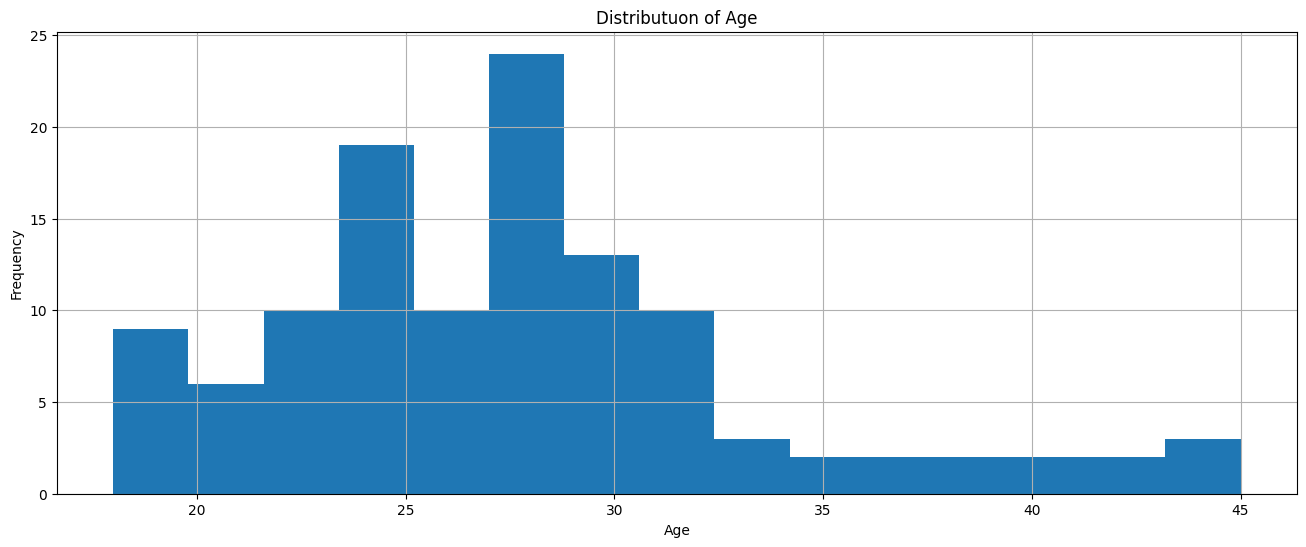

In [55]:
plt.figure(figsize=(16, 6))
plt.hist(df['age'], bins=15)
plt.title("Distributuon of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.grid()
plt.show()

Most ages are aorund 22 and 32/33. Ages in the 34 and 43 are relatively rare.

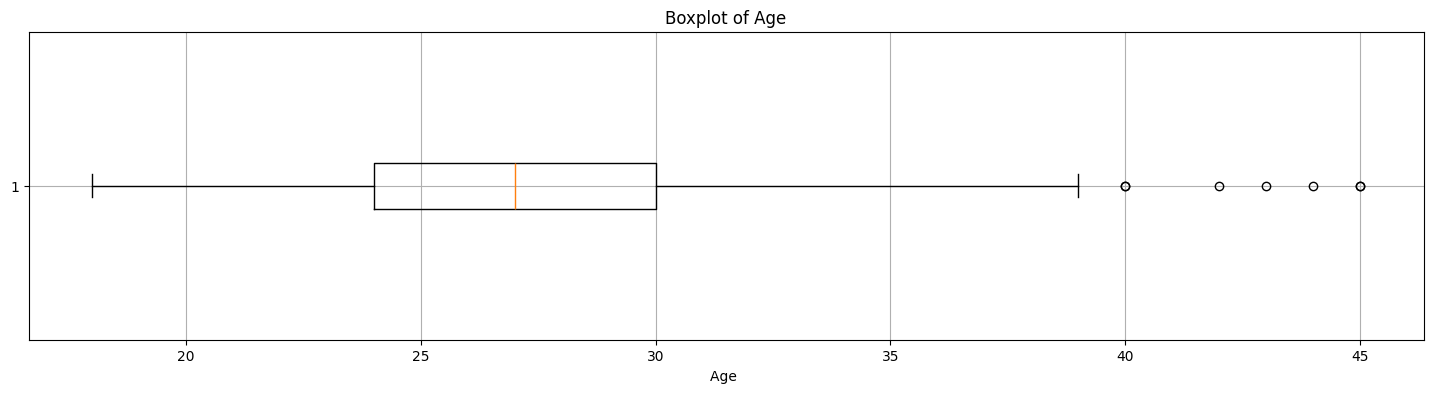

In [56]:
plt.figure(figsize=(18, 4))
plt.boxplot(df['age'], vert=False)
plt.xlabel("Age ")
plt.title("Boxplot of Age")
plt.grid()
plt.show()

The age boxplot shows the middle 50% od students are between 24 and 30 years old, median age is 27. The IQR i 6, 
giving a lower bound of 15 and an upper bound of 39. There are no lower-side outliers, while ages above 39 are identified as upper-side univariate outlier candidates. 

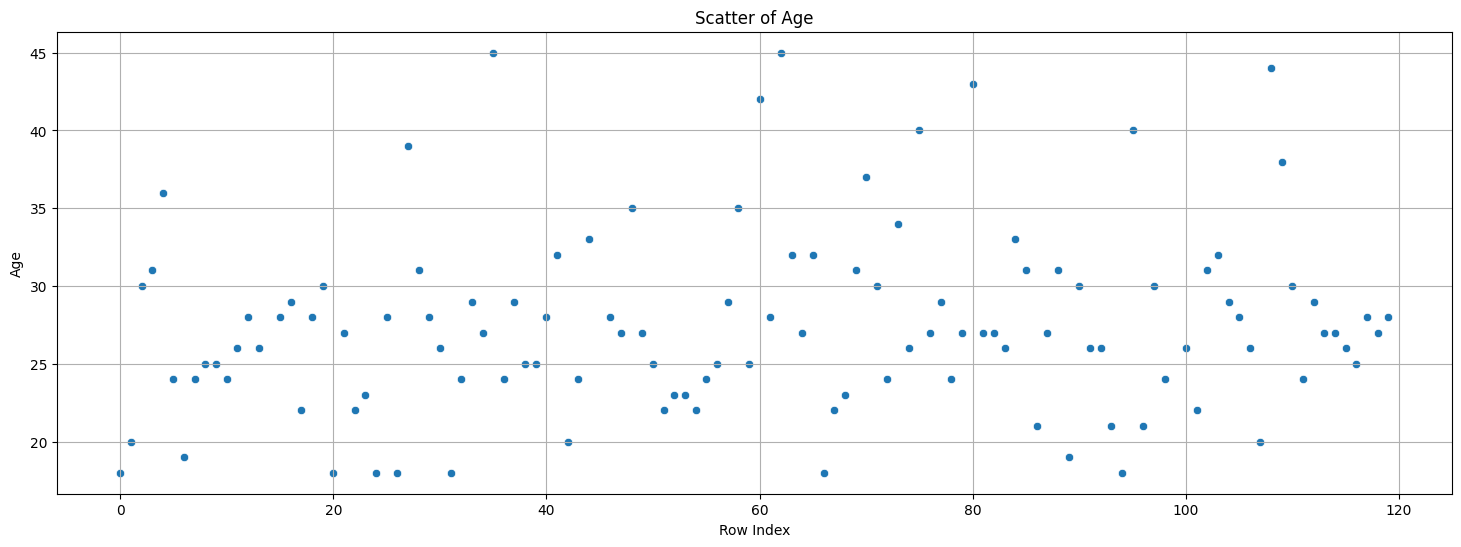

In [57]:
plt.figure(figsize=(18, 6))
sns.scatterplot(
    x=df.index, 
    y=df['age'])
plt.xlabel("Row Index")
plt.ylabel("Age")
plt.title("Scatter of Age")
plt.grid()
plt.show()

The scatter plot shows that most age observations are concentrated approximately between 18 and 33 years, while a small number of observations extend to 40–45 years.

In [58]:
df['age'].value_counts().sort_values()

age
43     1
44     1
38     1
34     1
39     1
42     1
37     1
36     1
45     2
19     2
33     2
35     2
40     2
21     3
20     3
32     4
23     4
30     6
31     6
22     6
18     7
29     7
25     8
26    10
24    11
28    11
27    13
Name: count, dtype: int64

#### Statistical Methods on **age** column 

##### IQR Method


IQR method detects observations that fall unusually far below Q1 and above Q3
- 1. Calculate Q1
- 2. Calculate Q3
- 3. Calculate IQR  **IQR=Q3−Q1**
- 4. Calculate lower bound **Lower Bound=Q1−1.5×IQR**
- 5. Calculate upper bound **Upper Bound=Q3+1.5×IQR**

In [59]:
# Calculate Q1 
Q1 = df['age'].quantile(0.25)
# calculate Q2
Q3 = df['age'].quantile(0.75)
# caculate IQR
IQR = Q3 - Q1
# calculate lower boundary
lower_boundary_age = Q1 - 1.5 * IQR
# calculate upper boundary
upper_boundary_age = Q3 + 1.5 * IQR

print(f"Age column Quantile 1: {Q1}")
print(f"Age column Quantile 3: {Q3}")
print(f"Age column IQR: {IQR}")
print(f"Age Column Lower Boundary: {lower_boundary_age}")
print(f"Age column Upper Boundary: {upper_boundary_age}")

Age column Quantile 1: 24.0
Age column Quantile 3: 30.0
Age column IQR: 6.0
Age Column Lower Boundary: 15.0
Age column Upper Boundary: 39.0


- 25% of age observations are age 24 or youger equivalently 55% are age 30 or older.
- 75% of age observations are age 30 or younger, equivalently 25% are age 30 or older.
- the middle 50% of age observations convers a range of 6 years, from 24 to 30. 
- Lower boundary age is 15 years old, no obserbations fall below the lower boundary.
- Upper boundary age is 39 years old, there are a few observed ages fall above upper bounday

In [60]:
# filtering rows with upper and lower boundaries
age_outliers_iqr = df[
    (df['age'] < lower_boundary_age) |
    (df['age'] > upper_boundary_age)
]
print(age_outliers_iqr[['student_id', 'age']].value_counts())
print(f"Total number of rows detected outliers by IQR: {len(age_outliers_iqr)}")

student_id  age
36          45     1
61          42     1
63          45     1
76          40     1
81          43     1
96          40     1
109         44     1
Name: count, dtype: int64
Total number of rows detected outliers by IQR: 7


By IQR method , 7 candidates are detected for univarite outliers

##### Z-score


Z-score asks: how many stardard deviations is each value away from the mean age ?                                                                                       
Z-score = (X - X_mean) / X_std

Common **Threshold value** 3 because 
In normal distribution:
- About 68% → within ±1 SD
- About 95% → within ±2 SD
- About 99.7% → within ±3 SD

Interpretation:
- Z < -3  → lower outlier candidate
- Z >  3  → upper outlier candidate

In [61]:
# calculate Mean age 
mean_age = df['age'].mean()
# Calculate Standard deviation 
std_age = df['age'].std()

# calculate z-score for each row
df['age_zscore'] = (df['age'] - mean_age) / std_age

df[['age', 'age_zscore']].sort_values('age_zscore', ascending=False).head(10)

,age,age_zscore
35,45,2.982582
62,45,2.982582
108,44,2.812771
80,43,2.642960
60,42,2.473148
75,40,2.133526
95,40,2.133526
27,39,1.963715
109,38,1.793903
70,37,1.624092


In [62]:
# applying common threshold=3
z_score_threshold = 3
age_zscore_outliers = df[
    df["age_zscore"].abs() > z_score_threshold
]

age_zscore_outliers[
    ["student_id", "age", "age_zscore"]
]

,student_id,age,age_zscore


Using the conventional threshold |Z| > 3, the Z-score method detects no univariate outliers in the age column.

##### Modified Z-score


Modified Z-score is more robust. In ordinary Z-score, std may be efficted by extreme values. For examplea: ges=[20, 22, 23, 24, 25, 26, 27, 100]. mean upward and std upward

But Motified Z-score Formula:                                                                                                                                         
    `Mᵢ = 0.6745 * (xᵢ - Median) / MAD`
- Mᵢ       = Modified Z-score of observation i
- xᵢ       = individual value
- Median   = median of the variable
- MAD      = Median Absolute Deviation
- 0.6745   = normalization constant

Common detection rule is:
`|Modified Z-score| > 3.5` → potential outlier

In [63]:
# take median age
median_age = df['age'].median()
# absolute deviation
absolute_deviation = abs(df['age'] - median_age)
# Median Absolute Deviation
mad_age = absolute_deviation.median()

# Modified Z-score
df['age_modified_zscore'] = (
    0.6745 * (df['age'] - median_age) / mad_age
)

# Detect outliers
threshold = 3.5
age_modified_z_outliers = df[
    df["age_modified_zscore"].abs() > threshold
]
age_modified_z_outliers[['age', 'age_modified_zscore']]

,age,age_modified_zscore
35,45,4.047000
62,45,4.047000
80,43,3.597333
108,44,3.822167


#### Final Conclution: **Age** Column 

`Age` distribution ranges from 18-45 years and it is moderately right-skewed with positive kurtosis or heavy tails. Visual analysis shows that most observations are concenterated around ages 24-30, with a right tail extending to 45. The `IQR` method identified seven observations aged 40-45 as outlier candidates, while the `Modified Z-score` identified the more exreme ages 43-45. The ordinary `Z-score` with a threshold 3 detects no outlier. Overall, the analysis provides evidence of statistically unusual gigh-age observations with ages 43-45. 

#### Treating **Age** column univate outliers

Algiught the ages 40-45 are statistically outlier candidates, they are valid logically I keep them.

## Multivariate Outliers

### Identifying Multivariate Groups

In [64]:
df.head()

,student_id,date,program,city,gender,employment_status,age,study_hours_week,sleep_hours,attendance_rate,assignment_score,exam_score,survey_satisfaction,stress_level,monthly_income_pln,season,temperature_c,campaign,website_visits,usual_country,login_country,purchase_amount,transaction_hour,failed_logins_5min,requests_per_minute,batch_id,defective_count,age_zscore,age_modified_zscore
0,1,2026-01-01,Data Science,Warsaw,Female,Part-time,18,9.8,6.2,85.0,78.3,79.1,5.0,7.0,2197.000000,Winter,2.7,No Campaign,1014,Poland,Poland,107.98,20,0,122,B08,0,-1.602321,-2.023500
1,2,2026-01-02,Data Science,Katowice,Male,Student,20,10.1,7.4,98.6,83.4,88.3,3.0,6.0,1156.707317,Winter,-3.4,Exam Week,1855,Poland,Poland,63.76,16,2,83,B10,1,-1.262699,-1.573833
2,3,2026-01-03,Cybersecurity,Gdansk,Male,Part-time,30,9.6,7.4,82.5,79.5,77.8,3.0,3.0,4319.000000,Winter,-0.9,No Campaign,1079,Poland,Poland,79.54,12,1,111,B12,4,0.435413,0.674500
3,4,2026-01-04,Business IT,Krakow,Female,Part-time,31,14.5,7.0,78.6,83.5,75.9,4.0,5.0,4818.000000,Winter,4.6,Holiday Promo,2941,Poland,Poland,63.67,21,0,118,B09,5,0.605225,0.899333
4,5,2026-01-05,Business IT,Krakow,Female,Full-time,36,1.1,9.9,89.5,84.7,69.1,2.0,3.0,3122.000000,Winter,2.1,No Campaign,838,Poland,Poland,52.60,15,1,104,B01,3,1.454281,2.023500


##### Mutlivarite groups

1. Student performance
- **study_hours_week**
- **attendance_rate**
- **assignment_score**
- **exam_score**
****
2. Student wellbeing
- **sleep_hours**
- **survey_satisfaction**
- **stress_level**
****
3. Financial status
- **age**
- **monthly_income_pln**
- **employment_status**
****
4. Internet activity
- **requests_per_minute**
- **website_visits**
- **failed_logins_5min**
****

### Student Performance Multivarite columns

In [65]:
student_performance_col = cols = [
    "study_hours_week",
    "attendance_rate",
    "assignment_score",
    "exam_score"
]
performance_df = df[student_performance_col]


#### Scatter plots 

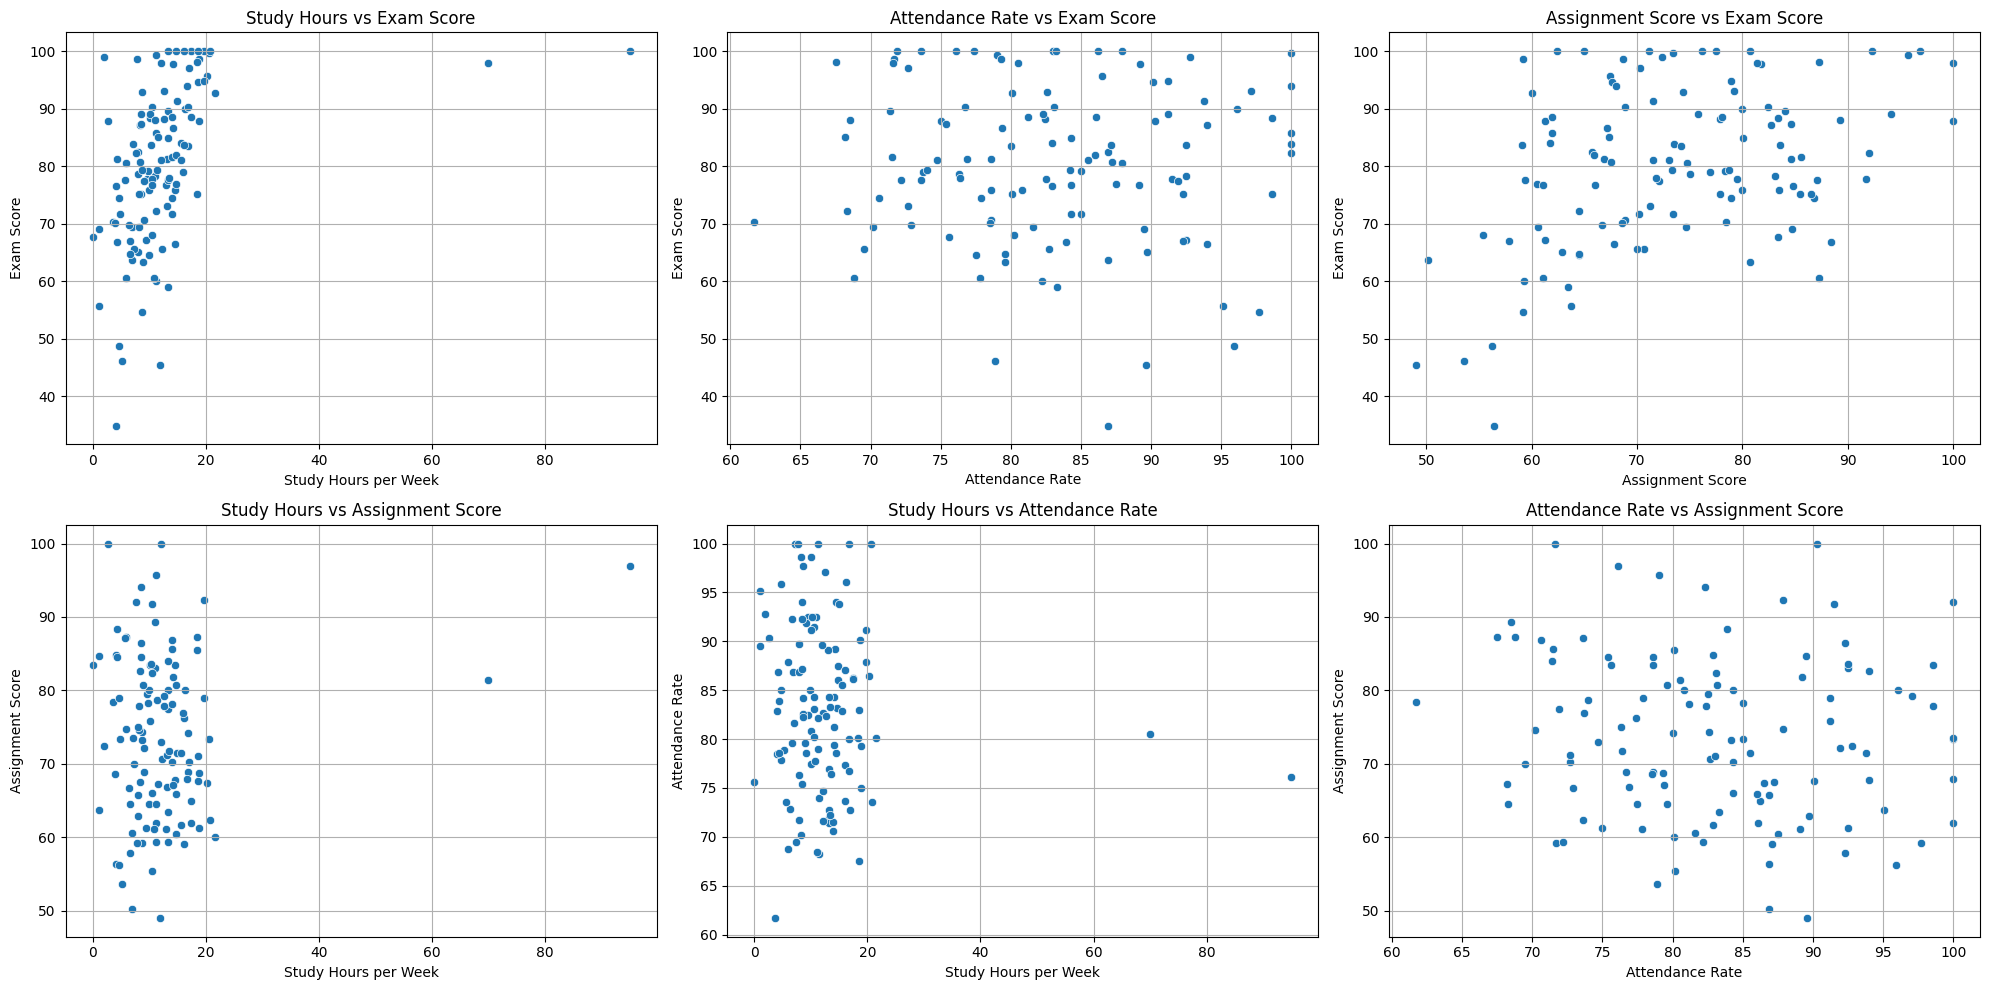

In [66]:

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(20, 10)
)

# 1. Study Hours vs Exam Score
sns.scatterplot(
    data=performance_df,
    x="study_hours_week",
    y="exam_score",
    ax=axes[0, 0]
)
axes[0, 0].set_title("Study Hours vs Exam Score")
axes[0, 0].set_xlabel("Study Hours per Week")
axes[0, 0].set_ylabel("Exam Score")
axes[0, 0].grid()

# 2. Attendance Rate vs Exam Score
sns.scatterplot(
    data=performance_df,
    x="attendance_rate",
    y="exam_score",
    ax=axes[0, 1]
)
axes[0, 1].set_title("Attendance Rate vs Exam Score")
axes[0, 1].set_xlabel("Attendance Rate")
axes[0, 1].set_ylabel("Exam Score")
axes[0, 1].grid()

# 3. Assignment Score vs Exam Score
sns.scatterplot(
    data=performance_df,
    x="assignment_score",
    y="exam_score",
    ax=axes[0, 2]
)
axes[0, 2].set_title("Assignment Score vs Exam Score")
axes[0, 2].set_xlabel("Assignment Score")
axes[0, 2].set_ylabel("Exam Score")
axes[0, 2].grid()

# 4. Study Hours vs Assignment Score
sns.scatterplot(
    data=performance_df,
    x="study_hours_week",
    y="assignment_score",
    ax=axes[1, 0]
)
axes[1, 0].set_title("Study Hours vs Assignment Score")
axes[1, 0].set_xlabel("Study Hours per Week")
axes[1, 0].set_ylabel("Assignment Score")
axes[1, 0].grid()

# 5. Study Hours vs Attendance Rate
sns.scatterplot(
    data=performance_df,
    x="study_hours_week",
    y="attendance_rate",
    ax=axes[1, 1]
)
axes[1, 1].set_title("Study Hours vs Attendance Rate")
axes[1, 1].set_xlabel("Study Hours per Week")
axes[1, 1].set_ylabel("Attendance Rate")
axes[1, 1].grid()

# 6. Attendance Rate vs Assignment Score
sns.scatterplot(
    data=performance_df,
    x="attendance_rate",
    y="assignment_score",
    ax=axes[1, 2]
)
axes[1, 2].set_title("Attendance Rate vs Assignment Score")
axes[1, 2].set_xlabel("Attendance Rate")
axes[1, 2].set_ylabel("Assignment Score")
axes[1, 2].grid()

plt.tight_layout()
plt.show()

- **Study Hours vs Exam Score** From the plot, there is a general positive relationship, there are two clearly separated points exam_score near to 100 and study hours per week more 60 hours, and there are very unusal values that neary 0 study hours with verh high exam scores. 
- **Attendance Rate vs Exam Score** This plot shows a very weak or almost nonexistent linear relationship. there is one value very unusal, more than 85% attendance rate but, exam-score is very low about 20+
- **Assignment Score vs Exam Score** there is a visiable relationship, Higher assignment score -> Tendency toward higher exam score. There are some unsual values for example: exam-score is about 20 very less while assignment-score is near to 60
- **Study Hours vs Assignment Score** most values are Study hours: 2–22 and Assignment scores: approximately 50–100. there are extreme study hours per weer peek more than 60
- **Study Hours vs Attendance Rate** again that extremen study hours 
- **Attendance Rate vs Assignment Score** Most Values are Attendance: 65–100% and Assignment score: 50–100

In [67]:
performance_df[performance_df['study_hours_week']>60]

,study_hours_week,attendance_rate,assignment_score,exam_score
71,95.0,76.1,96.9,100.0
92,70.0,80.5,81.4,97.9


there are the two clear spread out values, based on dataset they may unsual but still they are possible values

In [68]:
performance_df[
    (performance_df['study_hours_week']<4) &
    (performance_df['exam_score'] > 80)
][['study_hours_week', 'exam_score']]

,study_hours_week,exam_score
65,2.0,99.0
95,2.7,87.8


these two dolumns values seem unusual in combination

In [69]:
performance_df[
    (performance_df['exam_score'] < 40) &
    (performance_df['attendance_rate'] > 85)
]

,study_hours_week,attendance_rate,assignment_score,exam_score
21,4.2,86.9,56.4,34.9


this value seems unusual , because attendance-rate is very high 85%, study-hours per week is normal 4.2 hours, assignment-score is a bit low 56.4

In [70]:
performance_df[
    (performance_df['exam_score'] < 40) &
    (performance_df['assignment_score'] < 60)
]

,study_hours_week,attendance_rate,assignment_score,exam_score
21,4.2,86.9,56.4,34.9


In [71]:
performance_df[
    (performance_df['attendance_rate'] < 65) &
    (performance_df['assignment_score'] < 50)
]

,study_hours_week,attendance_rate,assignment_score,exam_score


#### Mahalanobis distance

Mahalanobis Distance asks: How unusual is a record (all multivariate group column values together) comparted to the center and covariance structure of all students      
Formula: `Dᵢ² = (xᵢ − μ)ᵀΣ⁻¹(xᵢ − μ)`
- xᵢ  = one student's performance vector
- μ   = mean vector
- Σ   = covariance matrix
- Σ⁻¹ = inverse covariance matrix
- D²  = squared Mahalanobis Distance

In [72]:
# 1. Select multivariate group
performance_cols = [
    "study_hours_week",
    "attendance_rate",
    "assignment_score",
    "exam_score"
]

# 2. Keep complete observations
performance_df = df[
    ["student_id"] + performance_cols
].dropna().copy()

# 3. Feature matrix
X = performance_df[performance_cols]
X.head()

,study_hours_week,attendance_rate,assignment_score,exam_score
0,9.8,85.0,78.3,79.1
1,10.1,98.6,83.4,88.3
2,9.6,82.5,79.5,77.8
3,14.5,78.6,83.5,75.9
4,1.1,89.5,84.7,69.1


In [73]:
from scipy.stats import chi2

# 4. Mean vector
mean_vector = X.mean().to_numpy()

# 5. Covariance matrix
cov_matrix = np.cov(
    X.to_numpy(),
    rowvar=False
)

# 6. Pseudo-inverse covariance matrix
inv_cov_matrix = np.linalg.pinv(
    cov_matrix
)

# 7. Difference from multivariate center
difference = (
    X.to_numpy() - mean_vector
)

# 8. Squared Mahalanobis Distance
mahalanobis_squared = np.einsum(
    "ij,jk,ik->i",
    difference,
    inv_cov_matrix,
    difference
)

performance_df["mahalanobis_squared"] = (
    mahalanobis_squared
)

performance_df["mahalanobis_distance"] = np.sqrt(
    mahalanobis_squared
)
performance_df.head()

,student_id,study_hours_week,attendance_rate,assignment_score,exam_score,mahalanobis_squared,mahalanobis_distance
0,1,9.8,85.0,78.3,79.1,0.378566,0.615277
1,2,10.1,98.6,83.4,88.3,4.577846,2.139590
2,3,9.6,82.5,79.5,77.8,0.503230,0.709387
3,4,14.5,78.6,83.5,75.9,1.621948,1.273557
4,5,1.1,89.5,84.7,69.1,4.053520,2.013335


`chi-sqaure` threshold 

In [74]:
# 9. Chi-square threshold
alpha = 0.99
n_features = len(performance_cols)

threshold = chi2.ppf(
    alpha,
    df=n_features
)
print(threshold)

13.276704135987622


performance_df threshold at 99% ≈ 13.277 -> Mahalanobis² -> 13.277
→ multivariate outlier candidate


In [75]:
# 10. Outlier flag
performance_df["mahalanobis_outlier"] = (
    performance_df["mahalanobis_squared"]
    > threshold
)

# 11. Display candidates
mahalanobis_outliers = performance_df[
    performance_df["mahalanobis_outlier"]
]

print("Threshold:", threshold)
print("Number of candidates:", len(mahalanobis_outliers))

print(mahalanobis_outliers)

Threshold: 13.276704135987622
Number of candidates: 2
    student_id  study_hours_week  attendance_rate  assignment_score  \
71          72              95.0             76.1              96.9   
92          93              70.0             80.5              81.4   

    exam_score  mahalanobis_squared  mahalanobis_distance  mahalanobis_outlier  
71       100.0            68.237248              8.260584                 True  
92        97.9            30.808359              5.550528                 True  


In [76]:
df[df['student_id'].isin([72, 93])][performance_cols]

,study_hours_week,attendance_rate,assignment_score,exam_score
71,95.0,76.1,96.9,100.0
92,70.0,80.5,81.4,97.9


Mahalanobis Dinstance is applied to `study_hours_week`, `attendance_rate`, `assignment_score` and `exam_score` columns. Using 99% chi-square threshold with 4 degress of freedom, two strong multivariate outlier candidates are detected students id 71 and 92. Both observations have extremly high weekly study hours combined with unsual overall performance profiles. 

#### Conclution on Student performance multivarite columns

The Student Performance group contains evidence of multivarite outloers. Pairwise scatter plots showed several visually unsual observations, especially students with exteme study hours and some unusual score combinations. Mahalanobis Distance the evaluated `study_hours_week`, `attendance_rate`, `assignment_score` and `exam_score` jointly. Using the 99% chi-square threshold, the strongest multivariate outlier candidates are the rcords at DataFrame indices 71 and 92 (stundets 72 and 93 if student_id = index + 1). These observations are unusually far from the overall multivariate performance pattern, mainly due to extremely high study hours combined with their complete attendance and performance.

#### Treatment

Since these two obersations are logically possible, I keep these values

## Contextual Value Outliers

In [77]:
df.head()

,student_id,date,program,city,gender,employment_status,age,study_hours_week,sleep_hours,attendance_rate,assignment_score,exam_score,survey_satisfaction,stress_level,monthly_income_pln,season,temperature_c,campaign,website_visits,usual_country,login_country,purchase_amount,transaction_hour,failed_logins_5min,requests_per_minute,batch_id,defective_count,age_zscore,age_modified_zscore
0,1,2026-01-01,Data Science,Warsaw,Female,Part-time,18,9.8,6.2,85.0,78.3,79.1,5.0,7.0,2197.000000,Winter,2.7,No Campaign,1014,Poland,Poland,107.98,20,0,122,B08,0,-1.602321,-2.023500
1,2,2026-01-02,Data Science,Katowice,Male,Student,20,10.1,7.4,98.6,83.4,88.3,3.0,6.0,1156.707317,Winter,-3.4,Exam Week,1855,Poland,Poland,63.76,16,2,83,B10,1,-1.262699,-1.573833
2,3,2026-01-03,Cybersecurity,Gdansk,Male,Part-time,30,9.6,7.4,82.5,79.5,77.8,3.0,3.0,4319.000000,Winter,-0.9,No Campaign,1079,Poland,Poland,79.54,12,1,111,B12,4,0.435413,0.674500
3,4,2026-01-04,Business IT,Krakow,Female,Part-time,31,14.5,7.0,78.6,83.5,75.9,4.0,5.0,4818.000000,Winter,4.6,Holiday Promo,2941,Poland,Poland,63.67,21,0,118,B09,5,0.605225,0.899333
4,5,2026-01-05,Business IT,Krakow,Female,Full-time,36,1.1,9.9,89.5,84.7,69.1,2.0,3.0,3122.000000,Winter,2.1,No Campaign,838,Poland,Poland,52.60,15,1,104,B01,3,1.454281,2.023500


#### Defining Context-behavior relationships

`Contextual column(s)` → `Behavioral Column`
Question: is a value unusual within a specific context ?
1. **season** → **temperature_c** 
2. **transaction_hour** → **purchase_amount**
3. **failed_logins_5min** → **requests_per_minute**
4. **usual_country**, **login_country** → **failed_logins_5min**


#### season → temperature_c context-behavior relationship

##### Describtive Statistics

In [78]:
season_temp_summary = (
    df.groupby(by='season')['temperature_c'].describe()
)
season_temp_summary

,count,mean,std,min,25%,50%,75%,max
season,,,,,,,,
Spring,60.0,13.413333,3.504547,4.1,11.325,13.4,15.725,21.3
Winter,57.0,0.803509,5.921600,-9.0,-2.000,-0.3,2.900,34.5


`Spring` temperatures are distributed around 13.4°C with moderate variation. `Winter` temperatures are mostly concentrated between −2.0°C and 2.9°C. However, the Winter maximum of 34.5°C is far above the typical Winter distribution and is a strong candidate for a contextual outlier.

##### Visualizations

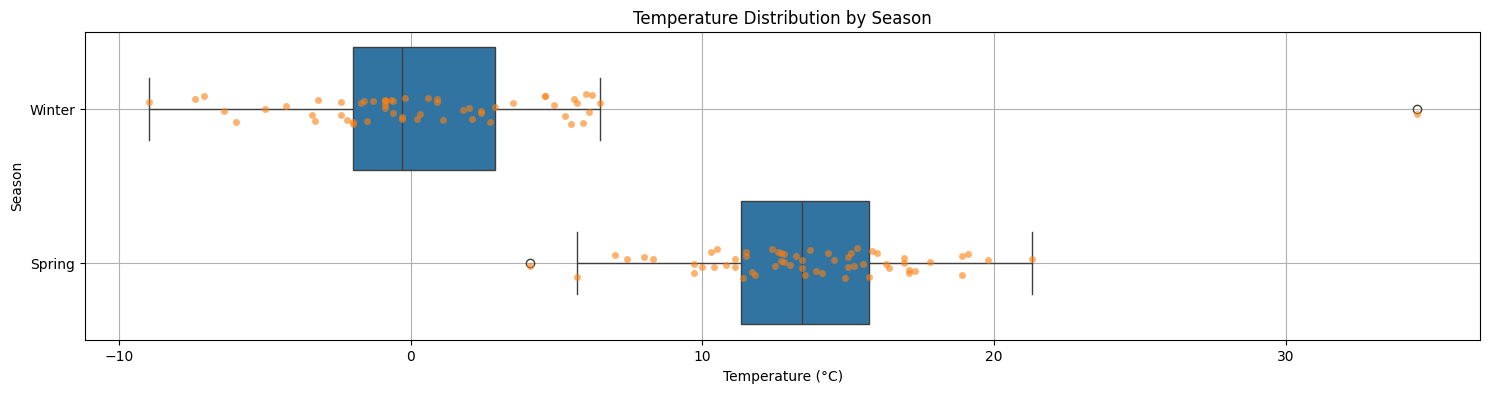

In [79]:
plt.figure(figsize=(18, 4))

sns.boxplot(
    data=df,
    x='temperature_c',
    y='season'
)

sns.stripplot(
    data=df,
    x='temperature_c',
    y='season',
    jitter=True,
    alpha=0.6
)

plt.title('Temperature Distribution by Season')
plt.xlabel('Temperature (°C)')
plt.ylabel('Season')
plt.grid()
plt.show()

for Spring most temperature are between roughly 11°C and 16°C, there is one low value  around. 4°C. For Winter, most temperatures are between approximately -2°C and 3°C, 34°C is extremenly far. 

##### IQR method

In [80]:
# For Spring 
spring_Q1 = df[df['season']=='Spring']['temperature_c'].quantile(0.25)
spring_Q3 = df[df['season']=='Spring']['temperature_c'].quantile(0.75)
spring_IQR = spring_Q3 - spring_Q1
lower_boundary_spring_temp = spring_Q1 - 1.5 * spring_IQR
upper_boundary_spring_temp = spring_Q3 + 1.5 * spring_IQR

print(f"Spirng Temperature Quantile 1: {spring_Q1}")
print(f"Spirng Temperature Quantile 3: {spring_Q3}")
print(f"Spirng Temperature IQR: {spring_IQR}")
print(f"Spirng Temperature Lower Boundary: {lower_boundary_spring_temp}")
print(f"Spirng Temperature Upper Boundary: {upper_boundary_spring_temp}")

Spirng Temperature Quantile 1: 11.325
Spirng Temperature Quantile 3: 15.725
Spirng Temperature IQR: 4.4
Spirng Temperature Lower Boundary: 4.724999999999999
Spirng Temperature Upper Boundary: 22.325


In [81]:
# For winter
winter_Q1 = df[df['season']=='Winter']['temperature_c'].quantile(0.25)
winter_Q3 = df[df['season']=='Winter']['temperature_c'].quantile(0.75)
winter_IQR = winter_Q3 - winter_Q1
lower_boundary_winter_temp = winter_Q1 - 1.5 * winter_IQR
upper_boundary_winter_temp = winter_Q3 + 1.5 * winter_IQR

print(f"Winter Temperature Quantile 1: {winter_Q1}")
print(f"Winter Temperature Quantile 3: {winter_Q3}")
print(f"Winter Temperature IQR: {winter_IQR}")
print(f"Winter Temperature Lower Boundary: {lower_boundary_winter_temp}")
print(f"Winter Temperature Upper Boundary: {upper_boundary_winter_temp}")


Winter Temperature Quantile 1: -2.0
Winter Temperature Quantile 3: 2.9
Winter Temperature IQR: 4.9
Winter Temperature Lower Boundary: -9.350000000000001
Winter Temperature Upper Boundary: 10.25


In [82]:
spring_temp_outliers = df[
    (df['season'] == 'Spring') &
    (
        (df['temperature_c'] < lower_boundary_spring_temp) |
        (df['temperature_c'] > upper_boundary_spring_temp)
    )
]
spring_temp_outliers[['season', 'temperature_c']]


,season,temperature_c
73,Spring,4.1


In [83]:
winter_temp_outliers = df[
    (df['season'] == 'Winter') &
    (
        (df['temperature_c'] < lower_boundary_winter_temp) |
        (df['temperature_c'] > upper_boundary_winter_temp)
    )
]
winter_temp_outliers[['season', 'temperature_c']]

,season,temperature_c
30,Winter,34.5


In [84]:
season_temp_outliers = pd.concat(
    [
        spring_temp_outliers,
        winter_temp_outliers
    ]
)

season_temp_outliers

,student_id,date,program,city,gender,employment_status,age,study_hours_week,sleep_hours,attendance_rate,assignment_score,exam_score,survey_satisfaction,stress_level,monthly_income_pln,season,temperature_c,campaign,website_visits,usual_country,login_country,purchase_amount,transaction_hour,failed_logins_5min,requests_per_minute,batch_id,defective_count,age_zscore,age_modified_zscore
73,74,2026-03-15,Business IT,Gdansk,Female,Full-time,34,11.2,6.1,68.3,64.5,72.2,3.0,3.0,5356.0,Spring,4.1,No Campaign,1051,Poland,Poland,44.83,13,0,122,B06,6,1.114658,1.573833
30,31,2026-01-31,Business IT,Warsaw,Female,Student,26,19.8,6.5,87.9,92.3,100.0,5.0,10.0,1595.0,Winter,34.5,No Campaign,1072,Poland,Poland,65.95,11,0,136,B01,6,-0.243832,-0.224833


In [85]:
season_temp_outliers[
    [
        'season',
        'temperature_c',
        'city',
        'date'
    ]
]

,season,temperature_c,city,date
73,Spring,4.1,Gdansk,2026-03-15
30,Winter,34.5,Warsaw,2026-01-31


Both values are statistical contextual outliers, but they should not recieve the same treatment. The Spring value 4.1°C is plausible, while Winter value 34.5°C is likely suspesuis.

##### Conclution 

The `Spring` value of `4.1°C` is below its season-specific lower IQR boundary of 4.725°C. However, it occurred in Gdansk on March 15, so it is still a` realistic early-Spring temperature`. It is statistically unusual within the dataset but logically plausible. So I keep it

The `Winter` value of `34.5°C` is far above the normal Winter distribution. It occurred in Warsaw on January 31 and is highly inconsistent with the other Winter observations. This is `a strong contextual outlier` and is likely caused by a data-entry or measurement error. It should be investigated and then corrected, imputed, or removed if the true value cannot be recovered.

## Collective Value Outliers